<a href="https://colab.research.google.com/github/LeonimerMelo/Recurrent-Networks/blob/LSTM/Introdu%C3%A7%C3%A3o_%C3%A0_rede_LSTM_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução à Rede LSTM para Séries Temporais

## O que é uma LSTM?

LSTM (Long Short-Term Memory) é um tipo especial de rede neural recorrente (RNN) projetada para **lembrar informações por longos períodos**. Enquanto RNNs tradicionais sofrem com o problema de "desaparecimento do gradiente" (esquecem informações antigas), as LSTMs foram criadas para resolver esse problema.

### Analogia Simples

Imagine que você está lendo um livro:
- Uma **RNN tradicional** é como ler e esquecer rapidamente: você lembra apenas das últimas palavras
- Uma **LSTM** é como ter um caderno de anotações: você pode guardar informações importantes do início do livro e usá-las no final

## Estrutura da LSTM

A LSTM possui três portas (gates) que controlam o fluxo de informações:

1. **Porta de Esquecimento (Forget Gate)**: Decide o que esquecer da memória anterior
2. **Porta de Entrada (Input Gate)**: Decide o que guardar na memória
3. **Porta de Saída (Output Gate)**: Decide o que usar como saída

```
         ┌──────────────────────────────────────┐
         │              LSTM Cell               │
         │                                      │
  h(t-1) │  ┌──────┐    ┌─────┐    ┌──────┐     │ h(t)
  ───────┼─>│Forget│    │Input│    │Output│  ───┼────────▶
         │  │Gate  │    │Gate │    │Gate  │     │
  x(t)   │  └──────┘    └─────┘    └──────┘     │
  ───────┼──────────────────────────────────────┘
         
```


<center><img src='https://drive.google.com/uc?id=1NOVZkMQbNm5PLL-Vg44hkdFYOzsdrgCW' width=1000></center>

As **LSTM (Long Short-Term Memory)** são uma arquitetura de **Redes Neurais Recorrentes (RNN - Recurrent Neural Networks)** criada para trabalhar com **dados sequenciais**, principalmente **séries temporais**, onde existe uma relação entre valores passados e futuros.

Exemplos de problemas que envolvem séries temporais:

* Previsão de temperatura;
* Previsão de consumo de energia;
* Cotação de ações;
* Demanda de produtos;
* Sensores industriais;
* Dados médicos;
* Tráfego de veículos;
* Previsão de vendas.

A principal vantagem da LSTM é conseguir **lembrar informações importantes de longo prazo** e esquecer informações irrelevantes.

---

# 1. Por que uma rede neural comum não é suficiente?

Considere uma série temporal:

```
Dia:       1    2    3    4    5    6
Temperatura:
          20   21   22   24   25   ?
```

Queremos prever o dia 6.

Uma rede neural tradicional recebe uma entrada:

```
X → Rede Neural → Y
```

Ela não sabe que existe uma ordem temporal.

Para ela:

```
20, 21, 22, 24, 25
```

é apenas um conjunto de números.

Mas uma série temporal possui dependência:

```
ontem influencia hoje
hoje influencia amanhã
```

---

# 2. A ideia da RNN

A rede recorrente introduz uma memória.

A cada instante:

```
X(t)
 |
 v
+-------------+
|     RNN     |
+-------------+
      |
      v
 memória h(t)
```

A saída anterior volta para a rede:

$$
h_t = f(X_t, h_{t-1})
$$

onde:

* $(X_t)$ = entrada atual
* $(h_{t-1})$ = memória anterior

Então a rede consegue lembrar:

```
Ontem → Hoje → Amanhã
```

---

# 3. Problema das RNN tradicionais

As RNN sofrem com:

## Vanishing Gradient

Durante o treinamento, o erro volta no tempo:

```
Erro
 |
 v
t5 ← t4 ← t3 ← t2 ← t1
```

Mas ele vai ficando pequeno:

```
0.9 → 0.4 → 0.1 → 0.001
```

A rede perde informações antigas.

Exemplo:

Frase:

> "Eu nasci no Brasil e moro lá porque minha família sempre viveu nesse país."

Para prever "Brasil", informações muito antigas podem ser necessárias.

A RNN tradicional esquece.

---

# 4. A solução: LSTM

A LSTM adiciona uma memória especial chamada:

## Cell State (estado da célula)

Ela funciona como uma "esteira de memória":

```
        Cell State
================================>
 t1    t2    t3    t4    t5
```

A LSTM decide:

* O que esquecer;
* O que guardar;
* O que usar agora.

---

# 5. Estrutura interna da LSTM

Uma célula LSTM possui três portas:

## 1) Forget Gate (porta de esquecimento)

Decide:

> O que deve ser apagado da memória?

Equação:

$$
f_t=\sigma(W_f[x_t,h_{t-1}]+b_f)
$$

Exemplo:

Memória:

```
Temperatura antiga:
30 graus
```

Nova informação:

```
Está no inverno
```

A LSTM pode reduzir a importância do passado.

---

## 2) Input Gate (porta de entrada)

Decide:

> Que informação nova guardar?

$$
i_t=\sigma(W_i[x_t,h_{t-1}]+b_i)
$$

---

## 3) Output Gate

Decide:

> O que enviar para a próxima camada?

$$
o_t=\sigma(W_o[x_t,h_{t-1}]+b_o)
$$

---

# 6. Fluxo simplificado

Uma LSTM funciona assim:

```
Entrada X(t)

      |
      v

+----------------+
| Forget Gate    |
+----------------+

      |
      v

+----------------+
| Input Gate     |
+----------------+

      |
      v

Memória Cell

      |
      v

+----------------+
| Output Gate    |
+----------------+

      |
      v

Previsão
```

---

# 7. Preparação de dados para LSTM

Uma LSTM espera dados no formato:

```
(amostras, passos_temporais, características)
```

Exemplo:

Queremos usar 5 dias para prever o sexto:

Dados:

```
Dia    Temperatura

1          20
2          21
3          22
4          24
5          25
6          26
```

Criamos:

Entrada:

```
[20,21,22,24,25]
```

Saída:

```
26
```

Forma:

```python
X.shape

(1,5,1)
```

Significado:

```
1 amostra
5 passos de tempo
1 variável
```

## Quando usar LSTM?

Boa escolha:

- ✅ Séries temporais longas
- ✅ Dependências de longo prazo
- ✅ Dados sequenciais
- ✅ Padrões complexos

Exemplos:

* Bolsa de valores;
* Energia;
* Clima;
* IoT;
* Voz;
* Texto.

---

##Limitações da LSTM

Apesar da eficiência:

* Treinamento mais lento;
* Muitas variáveis internas;
* Difícil interpretar;
* Pode exigir muitos dados.

Alternativas modernas:

* GRU (Gated Recurrent Unit);
* Transformers;
* Temporal Convolutional Networks (TCN).


##Exemplo Prático: Previsão de Vendas
Vamos criar um exemplo simples de previsão de vendas diárias usando LSTM

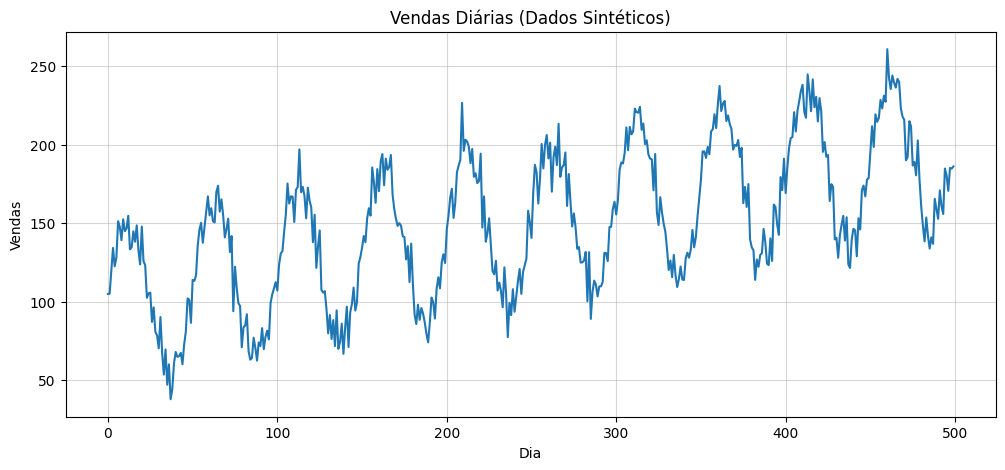

In [15]:
# Importar bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================
# PASSO 1: Criar dados sintéticos de vendas
# =============================================
np.random.seed(42)

# Criar 500 dias de vendas com tendência e sazonalidade
dias = 500
tendencia = np.linspace(100, 200, dias)  # Tendência crescente
sazonalidade = 50 * np.sin(np.linspace(0, 20*np.pi, dias))  # Sazonalidade
ruido = np.random.normal(0, 10, dias)  # Ruído aleatório

vendas = tendencia + sazonalidade + ruido
vendas = np.maximum(vendas, 0)  # Vendas não podem ser negativas

# Visualizar os dados
plt.figure(figsize=(12, 5))
plt.plot(vendas)
plt.title('Vendas Diárias (Dados Sintéticos)')
plt.xlabel('Dia')
plt.ylabel('Vendas')
plt.grid(True, alpha=0.5)
plt.show()

In [16]:
# Visualizando as primeiras vendas
print(f"Primeiros 10 dias de vendas: {vendas[:10].round(2)}")
print(f"Últimos 10 dias de vendas: {vendas[-10:].round(2)}")

Primeiros 10 dias de vendas: [104.97 105.1  119.34 134.27 122.59 128.1  151.28 147.66 139.18 152.52]
Últimos 10 dias de vendas: [152.83 170.93 160.79 155.9  184.79 180.46 170.58 185.24 184.76 186.17]


In [26]:
max(vendas).item()

260.85159785882854

In [27]:
min(vendas).item()

37.88970531783856

In [23]:
# =============================================
# PASSO 2: Preparar os dados para a LSTM
# =============================================

# Normalizar os dados (escalar entre 0 e 1)
scaler = MinMaxScaler(feature_range=(0, 1))
vendas_normalizadas = scaler.fit_transform(vendas.reshape(-1, 1))

print(f"Primeiros 10 dias de vendas normalizadas: {vendas_normalizadas[:10].round(2).reshape(-1)}")

Primeiros 10 dias de vendas normalizadas: [0.3  0.3  0.37 0.43 0.38 0.4  0.51 0.49 0.45 0.51]


In [28]:
max(vendas_normalizadas).item()

1.0

In [29]:
min(vendas_normalizadas).item()

0.0

In [30]:
# Função para criar sequências (look-back)
def criar_sequencias(dados, look_back=30):
    """
    Cria pares de entrada-saída para a LSTM

    Exemplo: Se look_back=3, usamos os dias [t-3, t-2, t-1] para prever o dia t
    """
    X, y = [], []
    for i in range(look_back, len(dados)):
        X.append(dados[i-look_back:i, 0])  # Entrada: últimos 'look_back' dias
        y.append(dados[i, 0])              # Saída: dia atual
    return np.array(X), np.array(y)

In [31]:
# Parâmetros
look_back = 30  # Usar 30 dias anteriores para prever o próximo

# Criar sequências
X, y = criar_sequencias(vendas_normalizadas, look_back)

# Dividir em treino (80%) e teste (20%)
tamanho_treino = int(len(X) * 0.8)
X_treino, X_teste = X[:tamanho_treino], X[tamanho_treino:]
y_treino, y_teste = y[:tamanho_treino], y[tamanho_treino:]

print(f"Dados de treino: {X_treino.shape}")
print(f"Dados de teste: {X_teste.shape}")

# A LSTM espera entrada no formato: [amostras, timesteps, features]
X_treino = X_treino.reshape(X_treino.shape[0], X_treino.shape[1], 1)
X_teste = X_teste.reshape(X_teste.shape[0], X_teste.shape[1], 1)

print(f"Dados de treino: {X_treino.shape}")
print(f"Dados de teste: {X_teste.shape}")

Dados de treino: (376, 30)
Dados de teste: (94, 30)
Dados de treino: (376, 30, 1)
Dados de teste: (94, 30, 1)


In [33]:
# =============================================
# PASSO 3: Construir o modelo LSTM
# =============================================

modelo = Sequential([
    Input((look_back, 1)),
    # Primeira camada LSTM com 50 neurônios
    # return_sequences=True porque vamos adicionar mais camadas LSTM
    LSTM(50, return_sequences=True),
    Dropout(0.2),  # Regularização para evitar overfitting

    # Segunda camada LSTM
    LSTM(50, return_sequences=False),
    Dropout(0.2),

    # Camada densa (fully connected)
    Dense(25, activation='relu'),

    # Camada de saída (1 neurônio para prever 1 valor)
    Dense(1)
])

# Compilar o modelo
modelo.compile(
    optimizer='adam',
    loss='mse',  # Erro quadrático médio
    metrics=['mae']  # Erro absoluto médio
)

# Resumo do modelo
modelo.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 30, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# =============================================
# PASSO 4: Treinar o modelo
# =============================================

# Treinar por 50 épocas
historico = modelo.fit(
    X_treino, y_treino,
    epochs=50,
    batch_size=32,
    validation_data=(X_teste, y_teste),
    verbose=2
)

Epoch 1/50
12/12 - 5s - 430ms/step - loss: 0.0874 - mae: 0.2393 - val_loss: 0.0231 - val_mae: 0.1319
Epoch 2/50
12/12 - 0s - 37ms/step - loss: 0.0294 - mae: 0.1436 - val_loss: 0.0247 - val_mae: 0.1315
Epoch 3/50
12/12 - 0s - 35ms/step - loss: 0.0224 - mae: 0.1270 - val_loss: 0.0223 - val_mae: 0.1252
Epoch 4/50
12/12 - 0s - 37ms/step - loss: 0.0199 - mae: 0.1186 - val_loss: 0.0165 - val_mae: 0.1094
Epoch 5/50
12/12 - 0s - 35ms/step - loss: 0.0151 - mae: 0.1033 - val_loss: 0.0150 - val_mae: 0.1043
Epoch 6/50
12/12 - 0s - 37ms/step - loss: 0.0129 - mae: 0.0935 - val_loss: 0.0080 - val_mae: 0.0762
Epoch 7/50
12/12 - 1s - 52ms/step - loss: 0.0086 - mae: 0.0761 - val_loss: 0.0137 - val_mae: 0.1036
Epoch 8/50
12/12 - 0s - 38ms/step - loss: 0.0076 - mae: 0.0692 - val_loss: 0.0124 - val_mae: 0.0981
Epoch 9/50
12/12 - 1s - 49ms/step - loss: 0.0071 - mae: 0.0667 - val_loss: 0.0084 - val_mae: 0.0791
Epoch 10/50
12/12 - 0s - 38ms/step - loss: 0.0073 - mae: 0.0668 - val_loss: 0.0074 - val_mae: 0.072

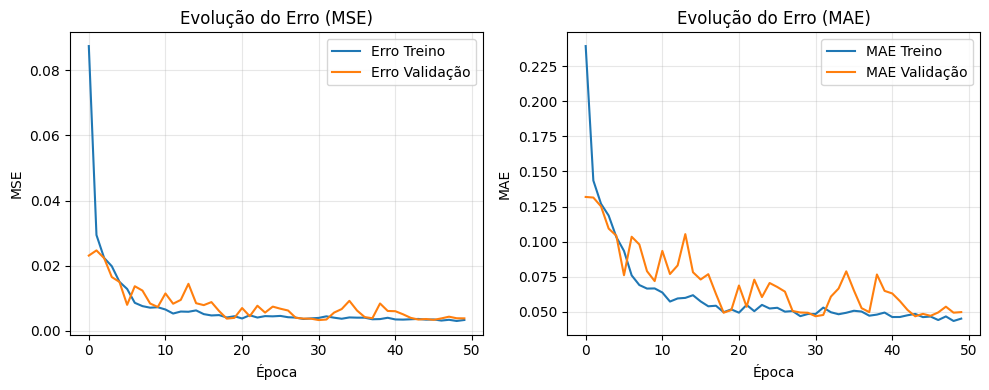

In [36]:
# Visualizar a evolução do erro durante o treinamento
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Treino')
plt.plot(historico.history['val_loss'], label='Erro Validação')
plt.title('Evolução do Erro (MSE)')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='MAE Treino')
plt.plot(historico.history['val_mae'], label='MAE Validação')
plt.title('Evolução do Erro (MAE)')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# =============================================
# PASSO 5: Fazer previsões
# =============================================

# Fazer previsões nos dados de teste
previsoes_normalizadas = modelo.predict(X_teste)

# Desnormalizar as previsões
previsoes = scaler.inverse_transform(previsoes_normalizadas)
valores_reais = scaler.inverse_transform(y_teste.reshape(-1, 1))

# =============================================
# PASSO 6: Avaliar o modelo
# =============================================

# Calcular métricas de erro
mse = mean_squared_error(valores_reais, previsoes)
rmse = np.sqrt(mse)
mae = mean_absolute_error(valores_reais, previsoes)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Raiz do Erro Quadrático Médio (RMSE): {rmse:.2f}")
print(f"Erro Absoluto Médio (MAE): {mae:.2f}")
print(f"Precisão Média (%): {(1 - mae/valores_reais.mean()) * 100:.1f}%")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 177ms/step
Erro Quadrático Médio (MSE): 192.03
Raiz do Erro Quadrático Médio (RMSE): 13.86
Erro Absoluto Médio (MAE): 11.13
Precisão Média (%): 94.1%


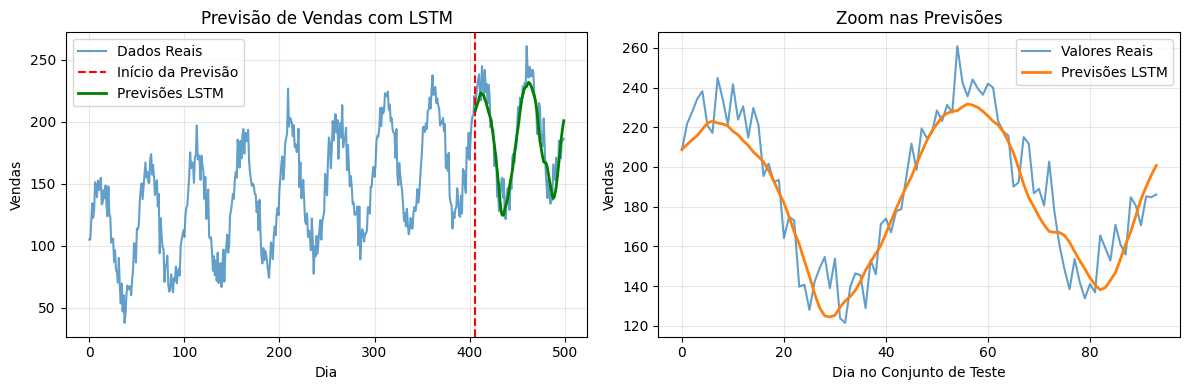

In [40]:
# =============================================
# PASSO 7: Visualizar os resultados
# =============================================

plt.figure(figsize=(12, 4))

# Plotar os dados completos
plt.subplot(1, 2, 1)
plt.plot(vendas, label='Dados Reais', alpha=0.7)

# Destacar a parte de teste
plt.axvline(x=len(vendas)-len(valores_reais), color='red',
            linestyle='--', label='Início da Previsão')

# Plotar as previsões no lugar certo
indices_previsao = range(len(vendas)-len(valores_reais), len(vendas))
plt.plot(indices_previsao, previsoes, color='green',
         label='Previsões LSTM', linewidth=2)

plt.title('Previsão de Vendas com LSTM')
plt.xlabel('Dia')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True, alpha=0.3)

# Zoom na parte de previsão
plt.subplot(1, 2, 2)
plt.plot(valores_reais, label='Valores Reais', alpha=0.7)
plt.plot(previsoes, label='Previsões LSTM', linewidth=2)
plt.title('Zoom nas Previsões')
plt.xlabel('Dia no Conjunto de Teste')
plt.ylabel('Vendas')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Explicação Passo a Passo do Código

### 1. Preparação dos Dados
```python
def criar_sequencias(dados, look_back=30):
    X, y = [], []
    for i in range(look_back, len(dados)):
        X.append(dados[i-look_back:i, 0])  # Entrada: sequência de 30 dias
        y.append(dados[i, 0])              # Saída: próximo dia
    return np.array(X), np.array(y)
```
Esta função transforma dados sequenciais em pares entrada-saída. Por exemplo:
- Se `look_back=3`, usamos os dias [1,2,3] para prever o dia 4
- Depois [2,3,4] para prever o dia 5, e assim por diante

### 2. Arquitetura LSTM
- **2 camadas LSTM com 50 neurônios**: A primeira retorna sequências, a segunda não
- **Dropout (20%)**: Desativa aleatoriamente 20% dos neurônios durante o treino para evitar overfitting
- **Camada Dense (25 neurônios)**: Processa a saída da LSTM
- **Camada de Saída (1 neurônio)**: Produz a previsão final

### 3. Normalização
Usamos `MinMaxScaler` para escalar os dados entre 0 e 1. Isso é crucial porque:
- A LSTM usa funções de ativação que funcionam melhor com dados normalizados
- Evita que características com valores grandes dominem o treinamento

### 4. Look-back (Janela de Tempo)
O parâmetro `look_back=30` significa que usamos 30 dias anteriores para prever o próximo dia. Esse valor deve ser escolhido com base no padrão dos dados.

## Quando Usar LSTM vs Outros Modelos

| Modelo | Melhor para | Exemplo |
|--------|------------|---------|
| **LSTM** | Dados com dependências de longo prazo | Previsão de ações, vendas sazonais |
| **ARIMA** | Dados com tendência linear | Séries econômicas simples |
| **Prophet** | Dados com forte sazonalidade | Previsão de tráfego web |
| **RNN Simples** | Dependências curtas | Previsão de curto prazo |

## Dicas para Melhores Resultados

1. **Ajuste o look_back**: Experimente diferentes janelas de tempo (7, 14, 30, 60 dias)
2. **Mais camadas**: Para dados mais complexos, adicione mais camadas LSTM
3. **Mais neurônios**: Aumente o número de neurônios para padrões mais complexos
4. **Regularização**: Ajuste o dropout para evitar overfitting
5. **Mais épocas**: Treine por mais épocas se o erro ainda estiver caindo

## Visualização da Arquitetura LSTM

```
Entrada: [batch, timesteps=30, features=1]
         ↓
    ┌──────────────────────┐
    │  LSTM Layer 1 (50)   │  ← Retorna sequências (return_sequences=True)
    │  Memória de longo    │
    │  prazo + curto prazo │
    └──────────────────────┘
         ↓
    ┌──────────────────────┐
    │     Dropout (20%)    │  ← Desativa neurônios aleatoriamente
    └──────────────────────┘
         ↓
    ┌──────────────────────┐
    │  LSTM Layer 2 (50)   │  ← Retorna apenas o último estado
    │  Memória de longo    │
    │  prazo + curto prazo │
    └──────────────────────┘
         ↓
    ┌──────────────────────┐
    │     Dropout (20%)    │
    └──────────────────────┘
         ↓
    ┌──────────────────────┐
    │ Dense Layer (25)     │  ← Processamento final
    │   ReLU Activation    │
    └──────────────────────┘
         ↓
    ┌──────────────────────┐
    │  Output Layer (1)    │  ← Previsão do próximo valor
    └──────────────────────┘
```

## Conclusão

A LSTM é uma ferramenta poderosa para séries temporais porque:
- **Lembra informações importantes** por longos períodos
- **Aprende padrões complexos** como sazonalidade e tendência
- **É flexível** para diferentes tipos de dados e problemas

O exemplo mostrou como criar um modelo LSTM para previsão de vendas, mas os mesmos princípios podem ser aplicados a dados financeiros, previsão de demanda, séries climáticas, e muitos outros domínios.